# Load-state check: experiments 95 & 96

Quick look at the **load state over time, per pod** for the two new runs, using the
existing `metrics.jsonl` scraping helper (`experiment_analysis.load_experiment_prom_samples`).

- **Exp 95** - external scrape of `7.150.2.142:8077` (bare vLLM, `metrics.jsonl` only). Has latency **percentiles**.
- **Exp 96** - internal `prod_latency_collector` (router `10.50.156.65`). Also has `logs.json`, `vllm-logs/`, and **router-side** metrics; latency is **averages** only.

Note: this capture (2026-07-11) predates the `*_rpm` / cumulative-token fields, so
per-minute values are derived in-notebook as `per_sec * 60` (shown on the right axis of each rate panel).

## Canonical endpoint mapping

The three data sources identify pods differently, so every cell normalizes to one
canonical **endpoint** label. The IP<->name mapping is **confirmed** from each pod's
own `vllm.log` / `kv-sidecar.log` (not inferred from load):

| endpoint | server IP | role |
|---|---|---|
| `vllm-minimax-m2-0` | `7.150.6.33`  | ours |
| `vllm-minimax-m2-1` | `7.150.1.218` | ours |
| `them-142`          | `7.150.2.142` | external baseline (exp 95 target) |

- vLLM engine metrics (`metrics.jsonl`) are keyed by `IP:port:engine`; each of our
  servers runs **2 DP engines**, kept visible as `...:0` / `...:1`.
- `logs.json` and sidecar metrics are keyed by pod name.
- `label_endpoints()` (setup cell) rewrites each row's `instance` to the canonical
  `endpoint_engine` name and adds `endpoint` (server-level) + `instance_raw` columns,
  so plots/tables show consistent names instead of a mix of IPs and pod names.

In [1]:
import os
import re
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from experiment_analysis import load_experiment_prom_samples

EXPERIMENTS_ROOT = "/home/saeid/llm-la/src/client/experiments"

# Per-second rate columns that also get a per-minute twin axis / companion.
_RATE_COLS = [
    "derived_rps", "request_success_per_sec",
    "prefill_tokens_per_sec", "gen_tokens_per_sec",
    "router_admission_rps", "router_outgoing_rps",
]
_RPM_MAP = {
    "derived_rps": "derived_rpm",
    "request_success_per_sec": "request_success_per_min",
    "prefill_tokens_per_sec": "prefill_tokens_per_min",
    "gen_tokens_per_sec": "gen_tokens_per_min",
    "router_admission_rps": "router_admission_rpm",
    "router_outgoing_rps": "router_outgoing_rpm",
}

# Canonical endpoint identity. The data mixes identifiers: vLLM engine metrics are
# keyed by IP:port:engine, while logs.json and sidecar metrics use the pod name.
# Mapping below is CONFIRMED from each pod's own vllm.log / kv-sidecar.log:
#   vllm-minimax-m2-0 -> 7.150.6.33   (ours)
#   vllm-minimax-m2-1 -> 7.150.1.218  (ours)
#   7.150.2.142                        -> them (external baseline)
ENDPOINT_MAP = {
    "7.150.6.33":        "vllm-minimax-m2-0",  # ours
    "7.150.1.218":       "vllm-minimax-m2-1",  # ours
    "7.150.2.142":       "them-142",           # external baseline
    "vllm-minimax-m2-0": "vllm-minimax-m2-0",
    "vllm-minimax-m2-1": "vllm-minimax-m2-1",
}
US_ENDPOINTS = ("vllm-minimax-m2-0", "vllm-minimax-m2-1")
THEM_ENDPOINTS = ("them-142",)


def _parse_endpoint(instance):
    """Map any identifier -> (endpoint_name, engine_rank_or_None).

    engine_rank is only kept for the IP:port:rank vLLM rows so we can still see the
    two DP engines per endpoint; name/sidecar rows collapse to the endpoint."""
    s = str(instance)
    for prefix, name in ENDPOINT_MAP.items():
        if s.startswith(prefix):
            rank = None
            if prefix.startswith("7.150"):
                m = re.search(r":(\d+)$", s)
                if m:
                    rank = m.group(1)
            return name, rank
    return None, None


def label_endpoints(df, col="instance"):
    """Add canonical `endpoint` (server-level) and `endpoint_engine` (with DP rank)
    columns, and rewrite the primary label `col` to the canonical name so every plot
    shows consistent endpoint names instead of a mix of IPs and pod names. The raw
    identifier is preserved in `instance_raw`."""
    df = df.copy()
    if col not in df.columns:
        return df
    ep, epe = [], []
    for v in df[col]:
        n, r = _parse_endpoint(v)
        ep.append(n)
        epe.append((f"{n}:{r}" if (n and r is not None) else n) if n else None)
    df["endpoint"] = ep
    df["endpoint_engine"] = epe
    df["instance_raw"] = df[col]
    df[col] = [e if e else raw for e, raw in zip(epe, df[col])]
    return df


def engine_rows(df, endpoints=None):
    """Keep only real vLLM engine metric rows (identified by a DP-engine rank, e.g.
    `...:0` / `...:1`), optionally restricted to the given canonical endpoints. Drops
    router (`172.16...`), model-name (`served-model-...`) and sidecar name-only rows
    that otherwise show up as flat zero lines in the per-pod plots."""
    d = df
    if "endpoint_engine" in d.columns:
        d = d[d["endpoint_engine"].astype(str).str.contains(":", na=False)]
    if endpoints is not None and "endpoint" in d.columns:
        d = d[d["endpoint"].isin(endpoints)]
    return d.copy()


def add_per_min(df):
    """This capture predates the *_rpm fields, so derive per-minute = per_sec * 60
    for whatever rate columns are present. Also add an elapsed-minutes x-axis."""
    df = df.copy()
    for rps, rpm in _RPM_MAP.items():
        if rps in df.columns and rpm not in df.columns:
            df[rpm] = df[rps] * 60.0
    if "ts" in df.columns and df["ts"].notna().any():
        t0 = df["ts"].min()
        df["elapsed_min"] = (df["ts"] - t0).dt.total_seconds() / 60.0
    df = label_endpoints(df, col="instance")  # unify IP/name -> canonical endpoint label
    return df


def load_summary(df):
    """Per-pod (instance) load-state summary (mean/max)."""
    cols = [c for c in [
        "requests_running", "requests_waiting",
        "derived_rps", "derived_rpm",
        "request_success_per_sec",
        "prefill_tokens_per_sec", "gen_tokens_per_sec",
        "kv_cache_usage_perc",
    ] if c in df.columns]
    if not cols or "instance" not in df.columns:
        return pd.DataFrame()
    return df.groupby("instance")[cols].agg(["mean", "max"]).round(2)


def _x60_twin(ax):
    """Right y-axis showing the same series in per-minute units (x60)."""
    lo, hi = ax.get_ylim()
    ax2 = ax.twinx()
    ax2.set_ylim(lo * 60.0, hi * 60.0)
    ax2.set_ylabel("per minute", fontsize=8)
    ax2.tick_params(labelsize=7)
    return ax2


def plot_series(df, cols, title):
    """One subplot per column; one line per pod (instance). Rate columns get a
    per-minute twin axis. Missing/all-NaN columns are skipped, NaNs dropped."""
    cols = [c for c in cols if c in df.columns and df[c].notna().any()]
    if not cols:
        print("no plottable columns for:", title)
        return
    x = "elapsed_min" if "elapsed_min" in df.columns else "ts"
    instances = sorted(df["instance"].dropna().unique())
    n = len(cols)
    fig, axes = plt.subplots(n, 1, figsize=(12, 2.6 * n), sharex=True)
    if n == 1:
        axes = [axes]
    for ax, col in zip(axes, cols):
        for inst in instances:
            sub = df[df["instance"] == inst].dropna(subset=[col])
            if sub.empty:
                continue
            ax.plot(sub[x], sub[col], label=str(inst), linewidth=1.2)
        ax.set_ylabel(col, fontsize=9)
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=7, ncol=2, loc="upper right")
        if col in _RATE_COLS:
            _x60_twin(ax)
    axes[-1].set_xlabel("elapsed (min)" if x == "elapsed_min" else "time (UTC)")
    fig.suptitle(title, fontsize=13, y=1.001)
    fig.tight_layout()
    plt.show()


def plot_load_state(df, title, extra_cols=None):
    """Standard per-pod load-state panels (queue depth, rps, token throughput, kv)."""
    base_cols = [
        "requests_running", "requests_waiting",
        "derived_rps", "request_success_per_sec",
        "prefill_tokens_per_sec", "gen_tokens_per_sec",
        "kv_cache_usage_perc",
    ]
    if extra_cols:
        base_cols = base_cols + list(extra_cols)
    plot_series(df, base_cols, title)

## Section A - Exp 95 (external scrape / `7.150.2.142`)

Bare vLLM, `metrics.jsonl` only. `derived_rps` is the flow-balance incoming estimate
(`request_success_per_sec + d(running+waiting)/dt`). Latency percentiles are available here.

exp 95 rows: 9528 | pods: ['them-142:0', 'them-142:1']


requests_running       requests_waiting      derived_rps        \
                       mean   max             mean  max        mean   max   
instance                                                                    
them-142:0             2.20  13.0              0.0  1.0        0.03  0.36   
them-142:1             1.98  14.0              0.0  1.0        0.03  0.36   

           derived_rpm        request_success_per_sec        \
                  mean    max                    mean   max   
instance                                                      
them-142:0        1.90  21.71                    0.03  0.36   
them-142:1        1.73  21.71                    0.03  0.36   

           prefill_tokens_per_sec           gen_tokens_per_sec          \
                             mean       max               mean     max   
instance                                                                 
them-142:0                1356.04  22207.79              42.00  132.84   
them-142:1                1205.99  25217.00              35.78  116.75   

           kv_cache_usage_perc        
                          mean   max  
instance                              
them-142:0                0.06  0.73  
them-142:1                0.06  0.66

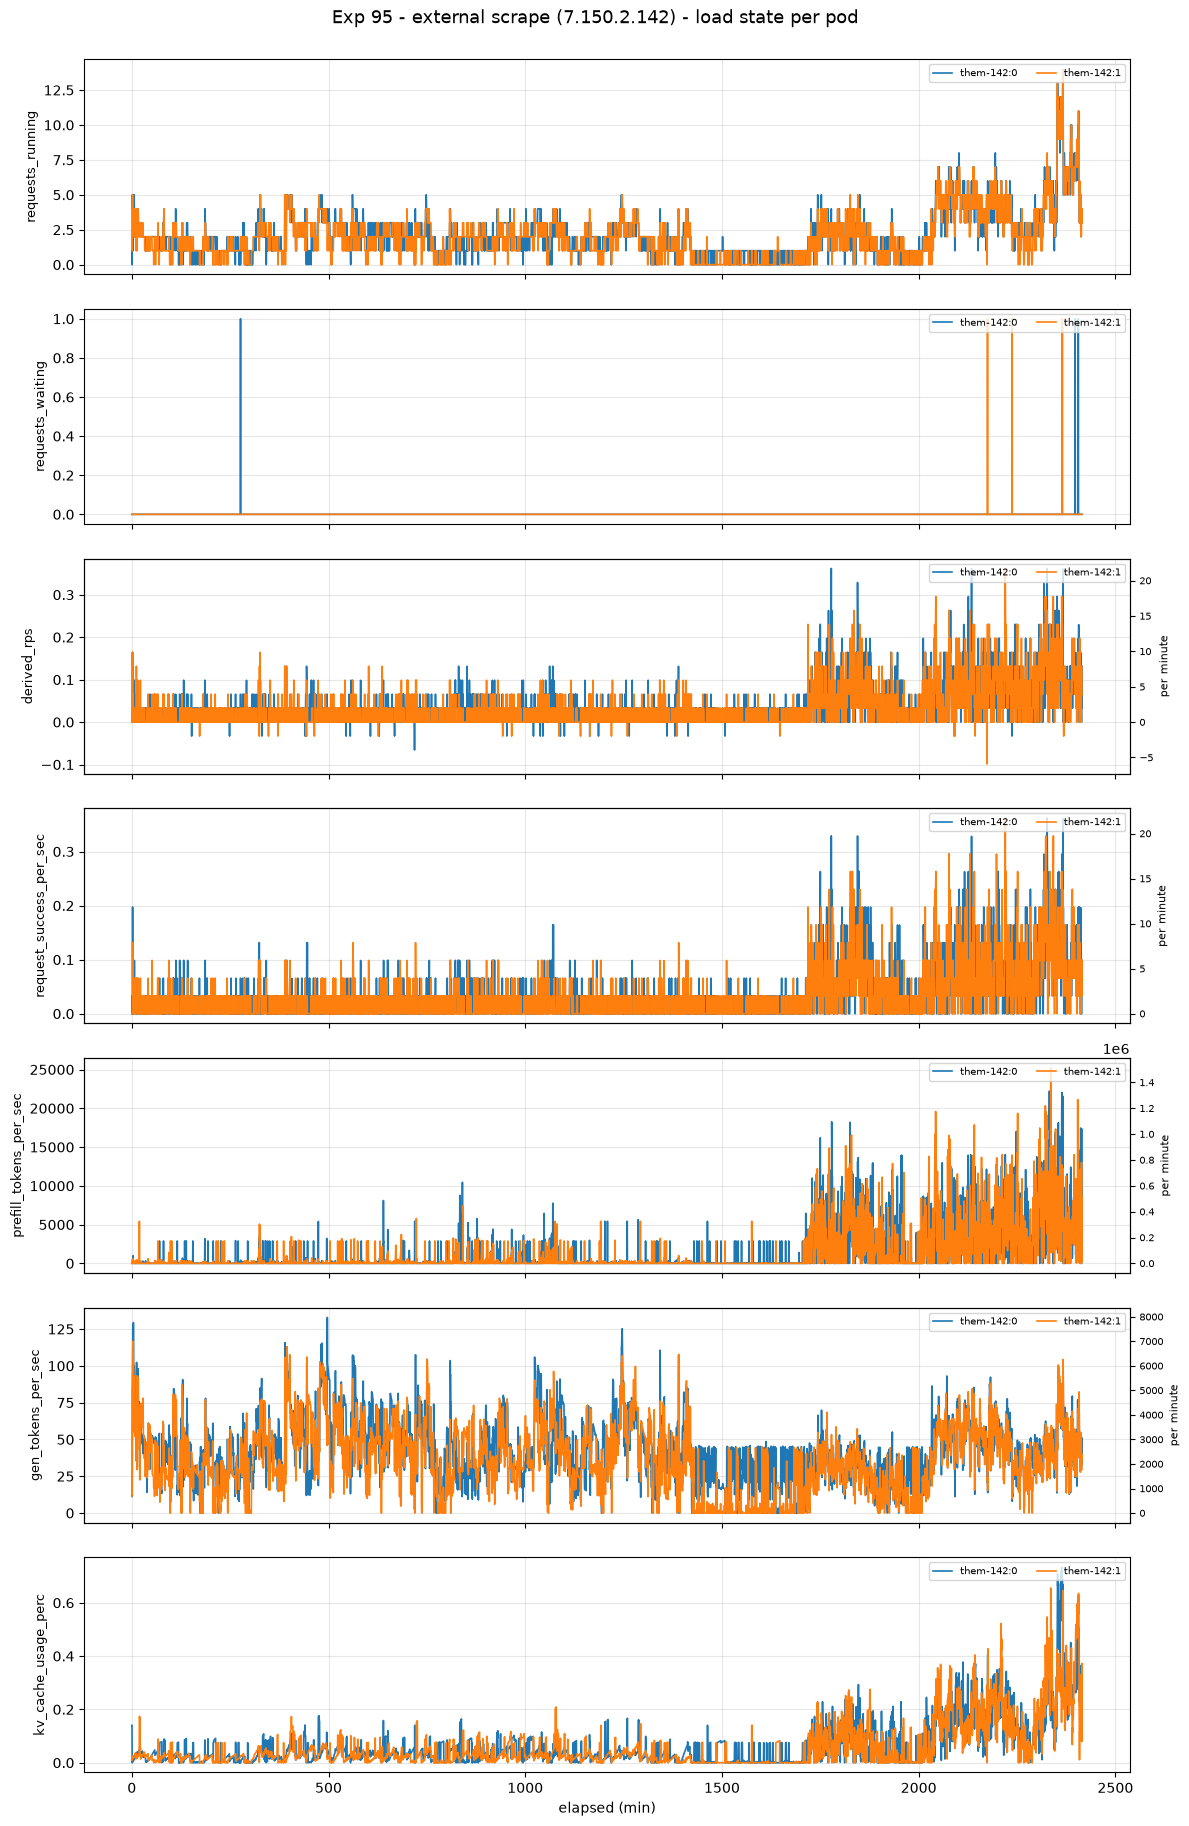

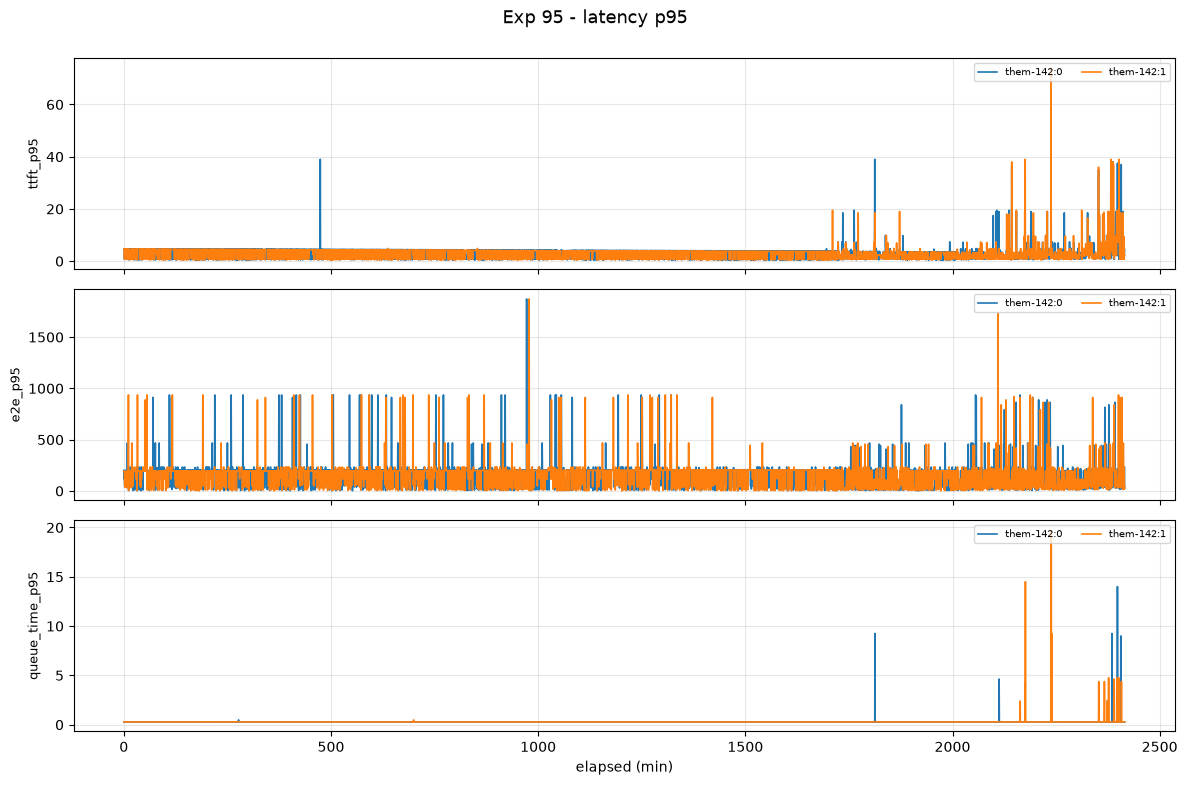

In [2]:
df95 = add_per_min(load_experiment_prom_samples(exp_id=95, experiments_root=EXPERIMENTS_ROOT))
print("exp 95 rows:", len(df95), "| pods:", sorted(df95["instance"].dropna().unique()))
display(load_summary(df95))
plot_load_state(df95, "Exp 95 - external scrape (7.150.2.142) - load state per pod")
plot_series(df95, ["ttft_p95", "e2e_p95", "queue_time_p95"], "Exp 95 - latency p95")

## Section B - Exp 96 (internal collector / router `10.50.156.65`)

Internal `prod_latency_collector`. Adds router-side metrics (`router_admission_rps`,
`router_outgoing_rps`, `router_queue_length`) which let us cross-check `derived_rps`
against the true incoming rate. Latency is averages only here.

exp 96 rows: 48060 | pods: ['172.16.135.4:8080', 'served-model-minmax', 'them-142:0', 'them-142:1', 'vllm-minimax-m2-0', 'vllm-minimax-m2-0:0', 'vllm-minimax-m2-0:1', 'vllm-minimax-m2-1', 'vllm-minimax-m2-1:0', 'vllm-minimax-m2-1:1']


requests_running       requests_waiting      derived_rps  \
                                mean   max             mean  max        mean   
instance                                                                       
vllm-minimax-m2-0:0             2.08  16.0              0.0  2.0        0.02   
vllm-minimax-m2-0:1             1.45  16.0              0.0  1.0        0.02   
vllm-minimax-m2-1:0             2.92  16.0              0.0  1.0        0.03   
vllm-minimax-m2-1:1             2.24  14.0              0.0  1.0        0.02   

                          derived_rpm        request_success_per_sec        \
                      max        mean    max                    mean   max   
instance                                                                     
vllm-minimax-m2-0:0  0.41        1.11  24.59                    0.02  0.34   
vllm-minimax-m2-0:1  0.31        0.98  18.46                    0.02  0.31   
vllm-minimax-m2-1:0  0.38        1.61  22.76                    0.03  0.38   
vllm-minimax-m2-1:1  0.31        1.19  18.62                    0.02  0.31   

                    prefill_tokens_per_sec           gen_tokens_per_sec  \
                                      mean       max               mean   
instance                                                                  
vllm-minimax-m2-0:0                 994.18  22801.34              23.87   
vllm-minimax-m2-0:1                 829.44  22067.59              16.23   
vllm-minimax-m2-1:0                1419.94  27520.55              27.43   
vllm-minimax-m2-1:1                 963.33  22432.54              21.66   

                             
                        max  
instance                     
vllm-minimax-m2-0:0  117.38  
vllm-minimax-m2-0:1  114.39  
vllm-minimax-m2-1:0  114.59  
vllm-minimax-m2-1:1  110.64

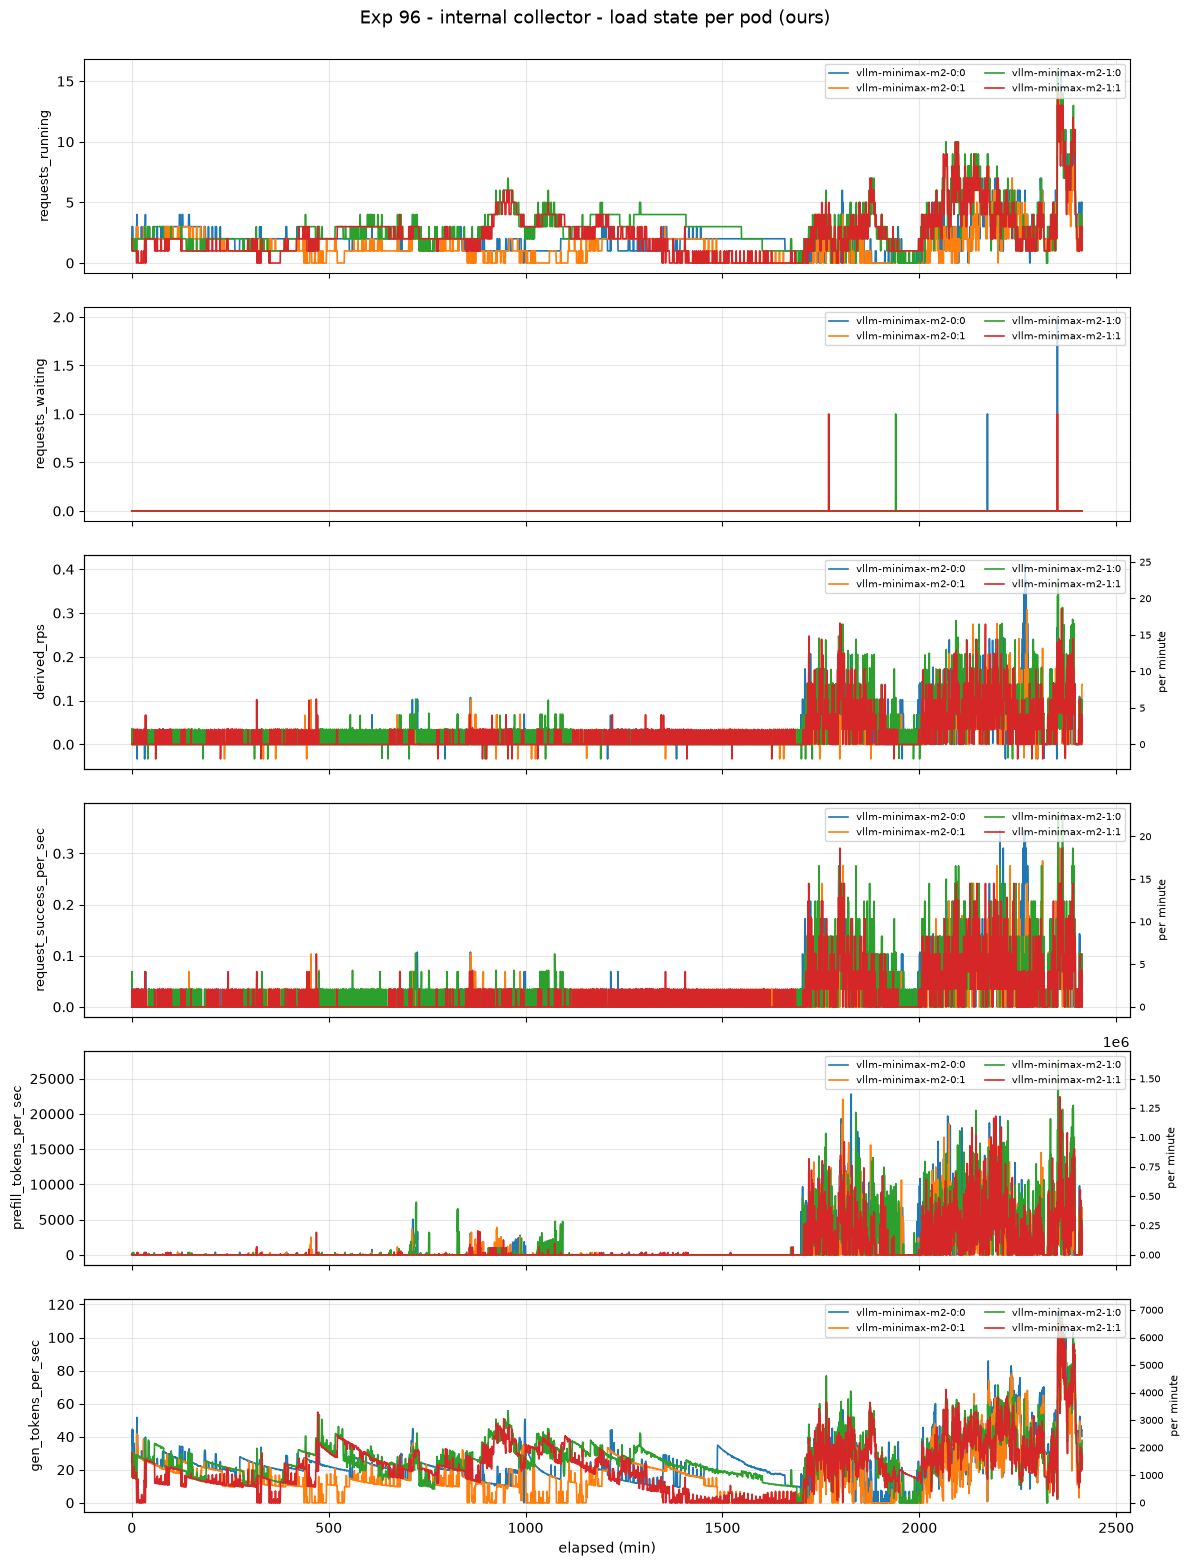

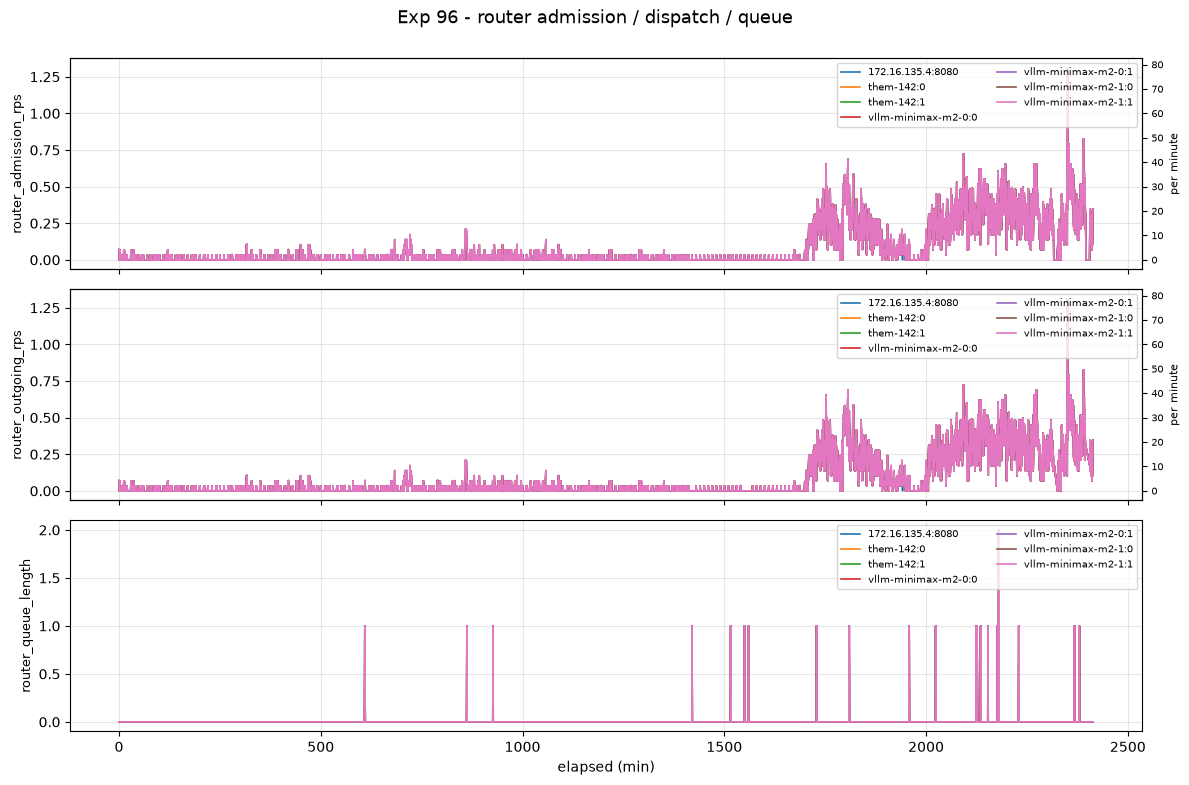

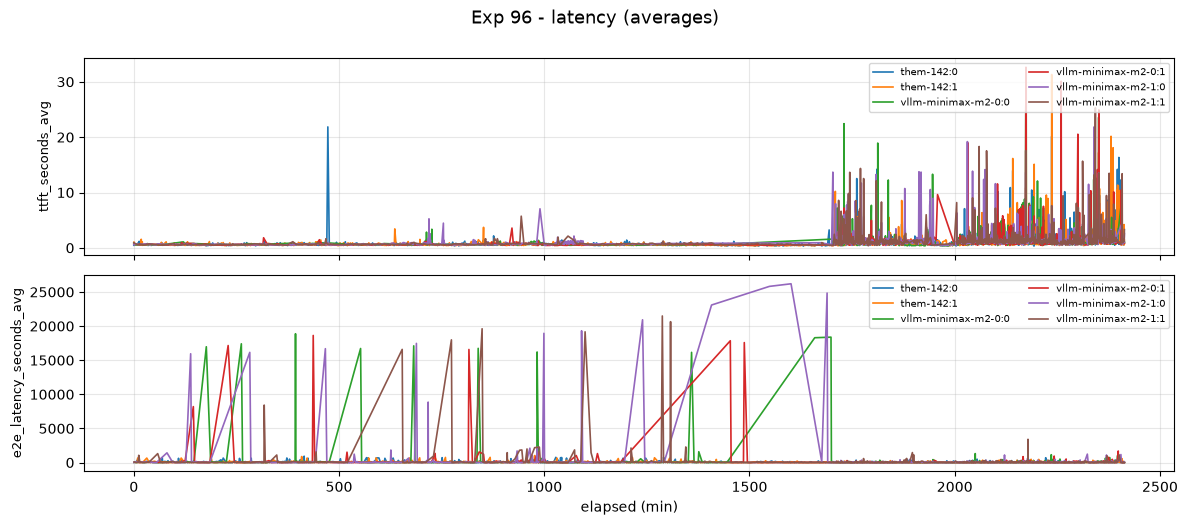

In [3]:
df96 = add_per_min(load_experiment_prom_samples(exp_id=96, experiments_root=EXPERIMENTS_ROOT))
print("exp 96 rows:", len(df96), "| pods:", sorted(df96["instance"].dropna().unique()))
display(load_summary(engine_rows(df96, US_ENDPOINTS)))
plot_load_state(engine_rows(df96, US_ENDPOINTS),
                "Exp 96 - internal collector - load state per pod (ours)")
# router-side panel (only the internal collector has these)
plot_series(df96, ["router_admission_rps", "router_outgoing_rps", "router_queue_length"],
            "Exp 96 - router admission / dispatch / queue")
plot_series(df96, ["ttft_seconds_avg", "e2e_latency_seconds_avg"], "Exp 96 - latency (averages)")

### Exp 96 - per-endpoint view (from `logs.json`, ours only)

The router's per-request truth (`logs.json`) is tagged with `endpoint_id` (our pods
`vllm-minimax-m2-0` / `-1`). This gives a finer, request-accurate per-endpoint breakdown than the
metrics scrape: request counts, token volume, latency percentiles, and KV-hit rate per endpoint,
plus load and cumulative work over time. (Exp 95 / them has no `logs.json`, so this is ours only.)

exp 96 logs.json requests: 12232 | endpoints: ['vllm-minimax-m2-0', 'vllm-minimax-m2-1']


,requests,prompt_tokens,completion_tokens,ttft_p50,ttft_p95,e2e_p50,e2e_p95,kv_hit_rate,req_share_%
endpoint_id,,,,,,,,,
vllm-minimax-m2-0,5178,283219792,2287657,1.618,5.468,15.712,133.291,0.249,42.3
vllm-minimax-m2-1,7054,373120897,2846804,1.792,4.730,19.139,159.411,0.187,57.7


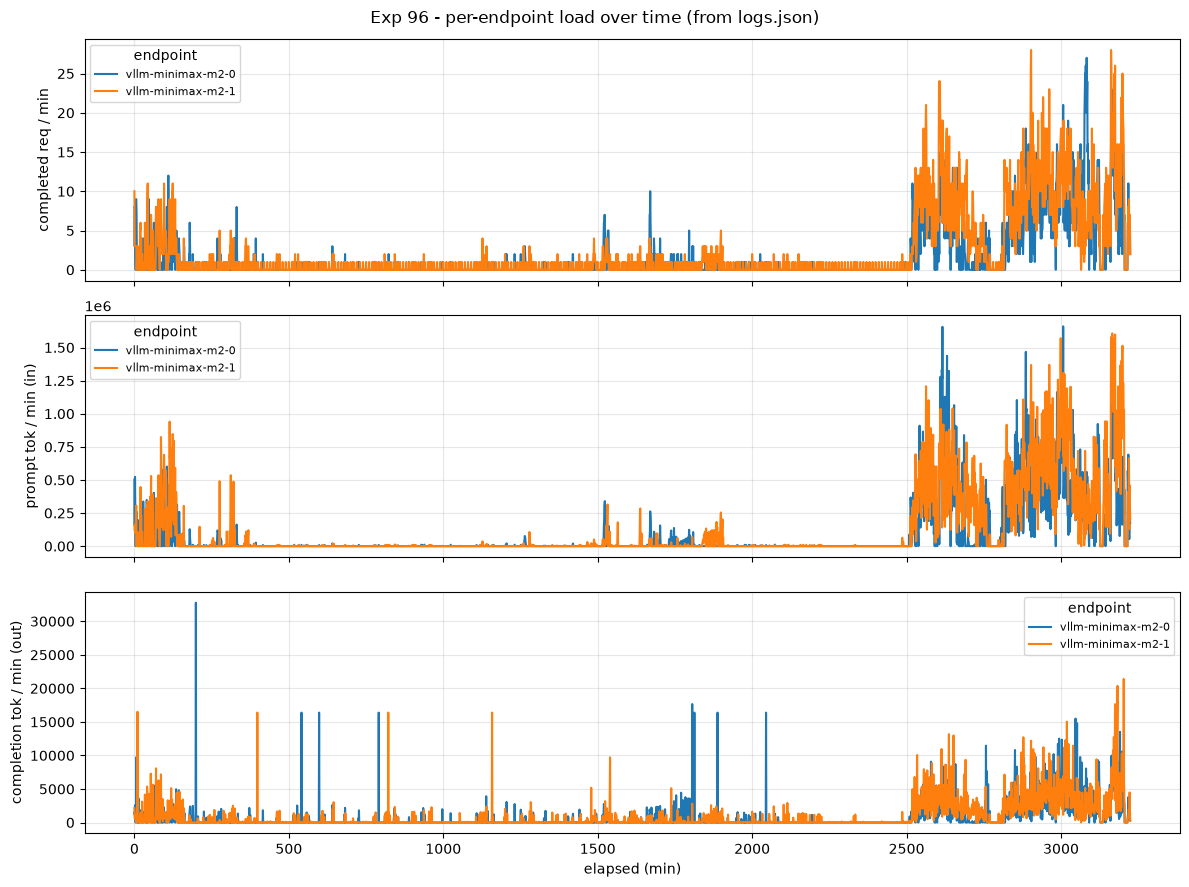

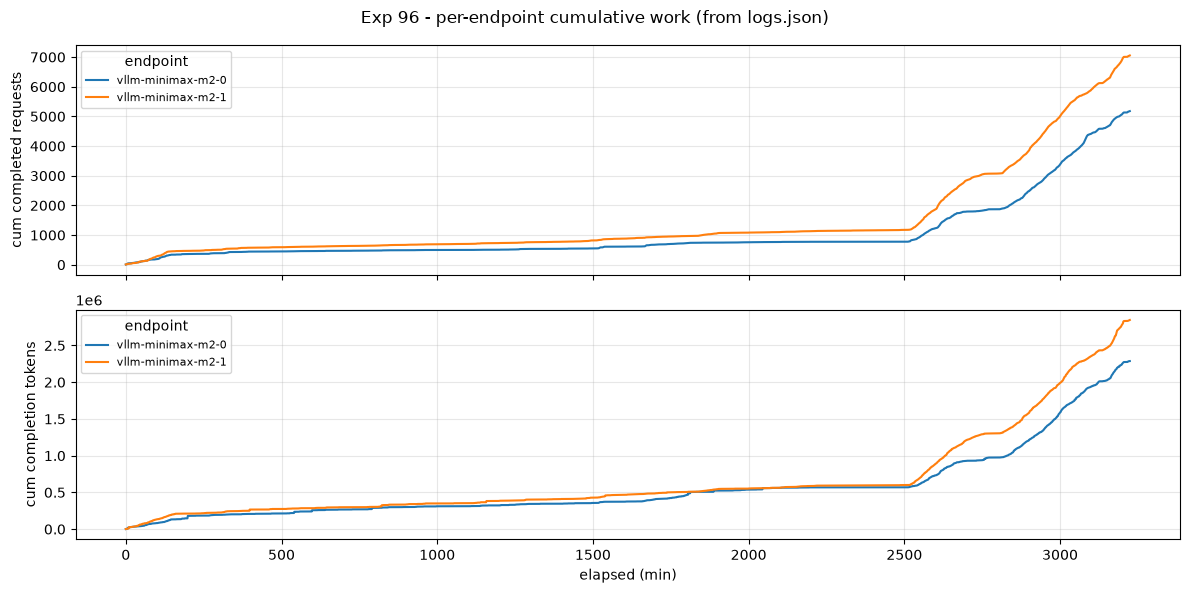

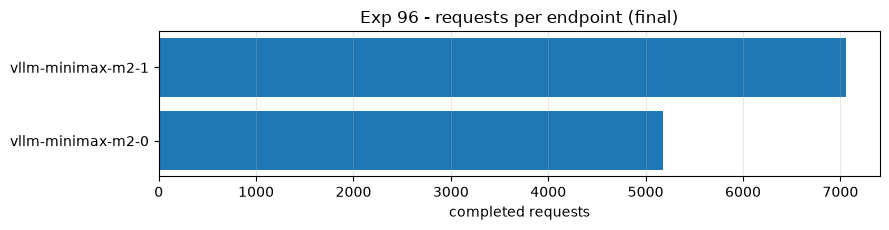

In [4]:
import json as _json
from pathlib import Path as _Path


def load_endpoint_logs(exp_id, experiments_root=EXPERIMENTS_ROOT):
    """Load per-request logs.json into a DataFrame (endpoint_id-tagged, ours only)."""
    p = _Path(experiments_root) / str(exp_id) / "logs.json"
    if not p.is_file():
        print("no logs.json for exp", exp_id)
        return pd.DataFrame()
    rows = []
    with open(p) as f:
        for line in f:
            line = line.strip()
            if line:
                try:
                    rows.append(_json.loads(line))
                except Exception:
                    pass
    df = pd.DataFrame(rows)
    for c in ("t0_wall", "t1_wall"):
        if c in df.columns:
            df[c] = pd.to_datetime(df[c], unit="s", utc=True)
    return df


def endpoint_summary(df):
    """Per-endpoint request/token/latency/KV summary."""
    if df.empty or "endpoint_id" not in df.columns:
        return pd.DataFrame()
    g = df.groupby("endpoint_id")
    out = pd.DataFrame({
        "requests": g.size(),
        "prompt_tokens": g["prompt_tokens"].sum(),
        "completion_tokens": g["completion_tokens"].sum(),
        "ttft_p50": g["ttft_s"].median(),
        "ttft_p95": g["ttft_s"].quantile(0.95),
        "e2e_p50": g["end_to_end_s"].median(),
        "e2e_p95": g["end_to_end_s"].quantile(0.95),
        "kv_hit_rate": g["kv_hit"].mean() if "kv_hit" in df.columns else np.nan,
    })
    out["req_share_%"] = (out["requests"] / out["requests"].sum() * 100).round(1)
    return out.round(3)


ep96 = load_endpoint_logs(96)
print("exp 96 logs.json requests:", len(ep96),
      "| endpoints:", sorted(ep96["endpoint_id"].dropna().unique()))
display(endpoint_summary(ep96))

# per-endpoint time series, bucketed by completion time (1-min buckets)
d = ep96.dropna(subset=["t1_wall"]).copy()
d["elapsed_min"] = ((d["t1_wall"] - d["t1_wall"].min()).dt.total_seconds() / 60.0).astype(int)
full = range(int(d["elapsed_min"].min()), int(d["elapsed_min"].max()) + 1)

rate = d.groupby(["elapsed_min", "endpoint_id"]).size().unstack(fill_value=0).reindex(full, fill_value=0)
tok_in = d.groupby(["elapsed_min", "endpoint_id"])["prompt_tokens"].sum().unstack(fill_value=0).reindex(full, fill_value=0)
tok_out = d.groupby(["elapsed_min", "endpoint_id"])["completion_tokens"].sum().unstack(fill_value=0).reindex(full, fill_value=0)

# load over time (per endpoint)
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
rate.plot(ax=axes[0]); axes[0].set_ylabel("completed req / min")
tok_in.plot(ax=axes[1]); axes[1].set_ylabel("prompt tok / min (in)")
tok_out.plot(ax=axes[2]); axes[2].set_ylabel("completion tok / min (out)")
for a in axes:
    a.grid(alpha=0.3); a.legend(fontsize=8, title="endpoint")
axes[-1].set_xlabel("elapsed (min)")
fig.suptitle("Exp 96 - per-endpoint load over time (from logs.json)")
fig.tight_layout(); plt.show()

# cumulative over time (per endpoint)
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
rate.cumsum().plot(ax=axes[0]); axes[0].set_ylabel("cum completed requests")
tok_out.cumsum().plot(ax=axes[1]); axes[1].set_ylabel("cum completion tokens")
for a in axes:
    a.grid(alpha=0.3); a.legend(fontsize=8, title="endpoint")
axes[-1].set_xlabel("elapsed (min)")
fig.suptitle("Exp 96 - per-endpoint cumulative work (from logs.json)")
fig.tight_layout(); plt.show()

# balance (final requests per endpoint)
cnt = d["endpoint_id"].value_counts()
fig, ax = plt.subplots(figsize=(9, 2.4))
ax.barh(cnt.index.astype(str), cnt.values); ax.invert_yaxis()
ax.set_xlabel("completed requests"); ax.grid(axis="x", alpha=0.3)
ax.set_title("Exp 96 - requests per endpoint (final)")
fig.tight_layout(); plt.show()

# Cumulative load over time (total work done per pod)

Instantaneous load (running/waiting/rps) shows the *rate*; this section shows the **running total**
per pod, which is what reveals load balance / fairness:

- **`cum_requests`** - cumulative completed requests, taken directly from the monotonic
  `request_success_total` counter (zero-based per pod).
- **`cum_prefill_tokens` / `cum_gen_tokens`** - cumulative incoming/outgoing tokens, obtained by
  time-integrating the per-second token rates (this capture has no cumulative token counters).

A flat gap between pod curves = imbalance; parallel curves = balanced load.

In [5]:
def add_cumulative(df):
    """Add per-pod cumulative work-done columns:
      - cum_requests: zero-based cumulative completed requests (from request_success_total)
      - cum_prefill_tokens / cum_gen_tokens: time-integral of the per-sec token rates
    Rows without those source fields (e.g. router/served-model rows) get NaN and are
    naturally skipped when plotting."""
    df = df.sort_values(["instance", "ts"]).copy()
    parts = []
    for _inst, g in df.groupby("instance", sort=False):
        g = g.copy()
        if "request_success_total" in g.columns and g["request_success_total"].notna().any():
            base = g["request_success_total"].dropna().iloc[0]
            g["cum_requests"] = g["request_success_total"] - base
        # resolution-safe seconds between scrapes (astype(int64) breaks under
        # pandas datetime64[us], silently scaling the integral by 1000).
        dt = g["ts"].diff().dt.total_seconds().fillna(0.0).clip(lower=0.0)
        for rate_col, cum_col in [("prefill_tokens_per_sec", "cum_prefill_tokens"),
                                  ("gen_tokens_per_sec", "cum_gen_tokens")]:
            if rate_col in g.columns:
                g[cum_col] = (g[rate_col].fillna(0.0) * dt).cumsum()
        parts.append(g)
    return pd.concat(parts, ignore_index=True)


_CUM_COLS = ["cum_requests", "cum_prefill_tokens", "cum_gen_tokens"]


def cumulative_totals(df):
    """Final cumulative total per pod (load-balance / fairness at a glance)."""
    cols = [c for c in _CUM_COLS if c in df.columns and df[c].notna().any()]
    if not cols or "instance" not in df.columns:
        return pd.DataFrame()
    out = df.sort_values("ts").groupby("instance")[cols].last().dropna(how="all")
    if "cum_requests" in out.columns and out["cum_requests"].sum() > 0:
        out["req_share_%"] = (out["cum_requests"] / out["cum_requests"].sum() * 100).round(1)
    return out.round(1)


def plot_cumulative(df, title):
    """Cumulative work-done curves, one line per pod."""
    cols = [c for c in _CUM_COLS if c in df.columns and df[c].notna().any()]
    if not cols:
        print("no cumulative columns for:", title)
        return
    x = "elapsed_min" if "elapsed_min" in df.columns else "ts"
    instances = sorted(df["instance"].dropna().unique())
    n = len(cols)
    fig, axes = plt.subplots(n, 1, figsize=(12, 2.8 * n), sharex=True)
    if n == 1:
        axes = [axes]
    for ax, col in zip(axes, cols):
        for inst in instances:
            sub = df[df["instance"] == inst].dropna(subset=[col])
            if sub.empty:
                continue
            ax.plot(sub[x], sub[col], label=str(inst), linewidth=1.4)
        ax.set_ylabel(col, fontsize=9)
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=7, ncol=2, loc="upper left")
    axes[-1].set_xlabel("elapsed (min)" if x == "elapsed_min" else "time (UTC)")
    fig.suptitle(title, fontsize=13, y=1.001)
    fig.tight_layout()
    plt.show()


def plot_cumulative_balance(df, title):
    """Bar chart of final cumulative completed requests per pod (imbalance view)."""
    tot = cumulative_totals(df)
    if tot.empty or "cum_requests" not in tot.columns:
        print("no cum_requests for:", title)
        return
    tot = tot.sort_values("cum_requests", ascending=False)
    fig, ax = plt.subplots(figsize=(10, 0.5 * len(tot) + 1.5))
    ax.barh([str(i) for i in tot.index], tot["cum_requests"])
    ax.invert_yaxis()
    ax.set_xlabel("cumulative completed requests")
    ax.grid(True, axis="x", alpha=0.3)
    ax.set_title(title, fontsize=12)
    fig.tight_layout()
    plt.show()

### Exp 95 - cumulative load per pod

,cum_requests,cum_prefill_tokens,cum_gen_tokens,req_share_%
instance,,,,
them-142:0,4595.0,196541504.7,6087276.2,52.3
them-142:1,4188.0,174786973.3,5185589.0,47.7


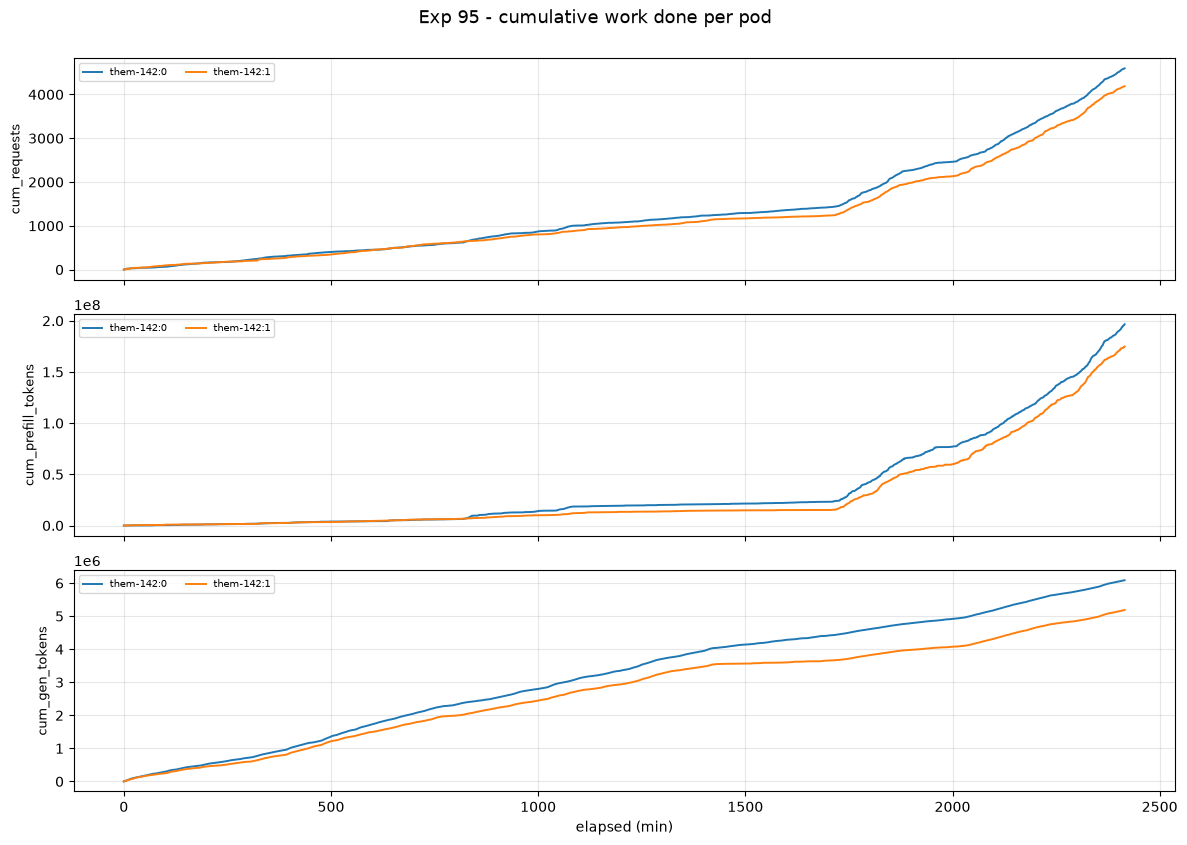

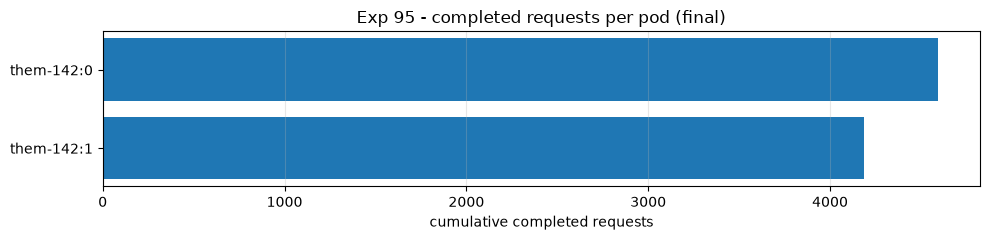

In [6]:
df95c = add_cumulative(engine_rows(df95))  # them-142 engines only (drops non-engine rows)
display(cumulative_totals(df95c))
plot_cumulative(df95c, "Exp 95 - cumulative work done per pod")
plot_cumulative_balance(df95c, "Exp 95 - completed requests per pod (final)")

### Exp 96 - cumulative load per pod

Non-engine rows (router / served-model) have no `request_success_total` or token rates, so they
drop out automatically and only the vLLM engines appear.

,cum_requests,cum_prefill_tokens,cum_gen_tokens,req_share_%
instance,,,,
vllm-minimax-m2-0:0,2685.0,144033317.9,3455802.3,22.7
vllm-minimax-m2-0:1,2366.0,120153920.6,2350214.4,20.0
vllm-minimax-m2-1:0,3910.0,205701308.8,3971843.3,33.0
vllm-minimax-m2-1:1,2892.0,139558594.3,3136707.4,24.4


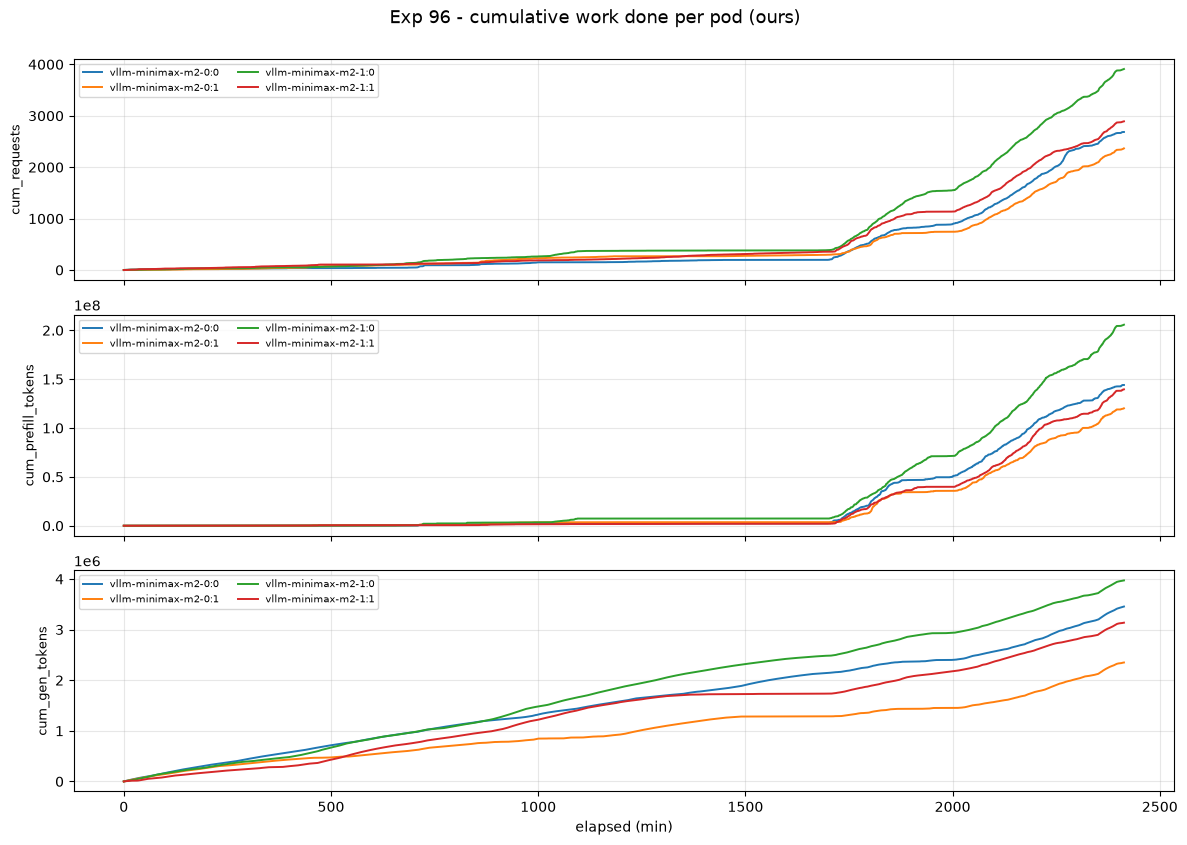

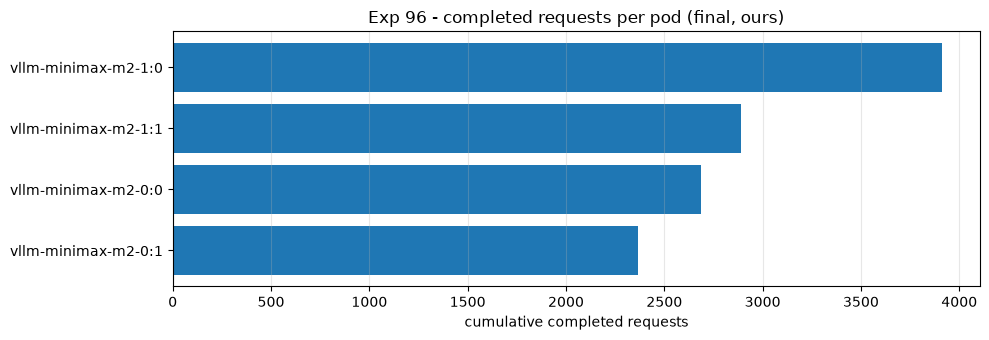

In [7]:
df96c = add_cumulative(engine_rows(df96, US_ENDPOINTS))  # our 4 engines only (no them-142/router/name rows)
display(cumulative_totals(df96c))
plot_cumulative(df96c, "Exp 96 - cumulative work done per pod (ours)")
plot_cumulative_balance(df96c, "Exp 96 - completed requests per pod (final, ours)")

# Them vs Us - total requests over time

Fleet-aggregated comparison of **them** vs **us**, aligned by elapsed time from each run's start.

- **them** = external baseline server `7.150.2.142` (2 engines), measured by exp 95.
- **us** = our two servers `7.150.1.218` + `7.150.6.33` (2 engines each = 4 engines), taken from exp 96.

Note: exp 96's collector also scraped the 142 server, but 142 is *them*, so it is **excluded** from
the "us" aggregation here. Cumulative curve uses the monotonic `request_success_total` counter summed
across the relevant pods per tick (completed requests as the proxy for total requests handled).
Totals are reported over the **common overlapping window** as well as each full run.

us endpoints: ['vllm-minimax-m2-0', 'vllm-minimax-m2-1'] | engines: ['vllm-minimax-m2-0', 'vllm-minimax-m2-0:0', 'vllm-minimax-m2-0:1', 'vllm-minimax-m2-1', 'vllm-minimax-m2-1:0', 'vllm-minimax-m2-1:1']


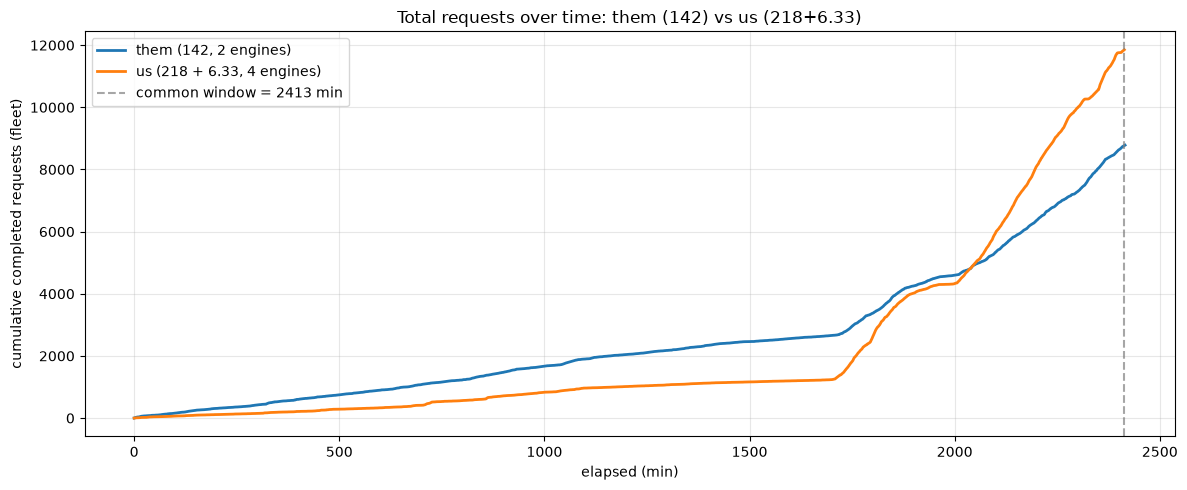

Common overlapping window: 2413.4 min
Over the common window, us handled 1.35x the requests of them (us per-engine: 2963, them per-engine: 4383).


,engines,duration_min,completed_@2413min,avg_rps_common,completed_full_run
run,,,,,
them (142),2,2415.3,8767,0.061,8783
us (218+6.33),4,2413.4,11853,0.082,11853


In [8]:
def fleet_series(df, col):
    """Sum a per-pod column across pods per tick -> fleet time series + elapsed_min."""
    if col not in df.columns:
        return pd.DataFrame(columns=["ts", "elapsed_min", col])
    d = df[df[col].notna()]
    if d.empty:
        return pd.DataFrame(columns=["ts", "elapsed_min", col])
    s = d.groupby("ts", as_index=False)[col].sum().sort_values("ts")
    t0 = s["ts"].min()
    s["elapsed_min"] = (s["ts"] - t0).dt.total_seconds() / 60.0
    return s


def fleet_cum_requests(df):
    """Fleet cumulative completed requests over time (zero-based)."""
    s = fleet_series(df, "request_success_total")
    if s.empty:
        return s
    s["cum_requests"] = s["request_success_total"] - s["request_success_total"].iloc[0]
    return s


def _cum_at(s, w):
    return float(np.interp(w, s["elapsed_min"], s["cum_requests"]))


# them = the 142 server (exp 95 measured only this).
them = fleet_cum_requests(df95)
# us = only our two endpoints within exp 96 (them-142 excluded; non-engine rows carry no
# request_success_total and drop out of the sum).
us_df = df96[df96["endpoint"].isin(US_ENDPOINTS)]
us = fleet_cum_requests(us_df)
print("us endpoints:", sorted(us_df["endpoint"].dropna().unique()),
      "| engines:", sorted(us_df["instance"].dropna().unique()))

# --- cumulative comparison ---
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(them["elapsed_min"], them["cum_requests"], lw=2, label="them (142, 2 engines)")
ax.plot(us["elapsed_min"], us["cum_requests"], lw=2, label="us (218 + 6.33, 4 engines)")
W = min(them["elapsed_min"].max(), us["elapsed_min"].max())
ax.axvline(W, ls="--", color="grey", alpha=0.7, label=f"common window = {W:.0f} min")
ax.set_xlabel("elapsed (min)")
ax.set_ylabel("cumulative completed requests (fleet)")
ax.grid(alpha=0.3)
ax.legend()
ax.set_title("Total requests over time: them (142) vs us (218+6.33)")
fig.tight_layout()
plt.show()

# --- totals summary ---
them_W, us_W = _cum_at(them, W), _cum_at(us, W)
them_full, us_full = them["cum_requests"].iloc[-1], us["cum_requests"].iloc[-1]
summary = pd.DataFrame({
    "run": ["them (142)", "us (218+6.33)"],
    "engines": [2, 4],
    "duration_min": [round(them["elapsed_min"].max(), 1), round(us["elapsed_min"].max(), 1)],
    f"completed_@{W:.0f}min": [round(them_W), round(us_W)],
    "avg_rps_common": [round(them_W / (W * 60), 3), round(us_W / (W * 60), 3)],
    "completed_full_run": [round(them_full), round(us_full)],
}).set_index("run")
print(f"Common overlapping window: {W:.1f} min")
if them_W > 0:
    print(f"Over the common window, us handled {us_W/them_W:.2f}x the requests of them "
          f"(us per-engine: {us_W/4:.0f}, them per-engine: {them_W/2:.0f}).")
display(summary)

# Them vs Us - latency & request size (short-request hypothesis)

Request counts are broadly similar, but them (142) show much lower e2e latency. We
test whether that's because they serve **shorter / cheaper requests**.

Method (same prometheus measurement for both, so the comparison is apples-to-apples):

- **e2e latency**: vLLM server-side average (`e2e_latency_seconds_avg`) is comparable
  for both. Percentiles differ in origin - them expose vLLM's own `e2e_p50/p95`, while
  for us only the router-side `router_e2e_p50/p95` exists (includes queue wait, so it
  is an upper bound, not directly comparable to them's server-side percentiles).
- **request size**: output tokens = integral of `gen_tokens_per_sec`; input/prompt
  tokens = integral of `prefill_tokens_per_sec`; divided by completed requests
  (`request_success_total` counter delta) for a duration-independent tokens/request.

**Findings**

- e2e latency: **CONFIRMED** - us server-side avg is ~6.9x them.
- **Prompt size is the driver**: them send ~25k input tok/req vs our ~40k (them ≈ 0.63x).
  Shorter prompts -> much less prefill work -> lower TTFT/e2e. Output volume is similar
  (~2.3k vs ~2.6k tok/req), so they are *not* simply cutting generations.
- **Overload amplifier (us only)**: `logs.json` shows we *deliver* only ~483 output
  tok/req but vLLM *generates* ~2.6k - a ~5x preemption/recompute blow-up, itself a
  symptom of the overload behind our high e2e. (them have no logs, but their light load
  implies little recompute.)

e2e_p50/p95: them = vLLM server-side; us = router-side (includes queue wait -> not directly comparable).
CONFIRMED: server-side avg e2e for us is 3.2x them.


,engines,e2e_avg_s (vLLM),ttft_avg_s (vLLM),e2e_p50_s,e2e_p95_s
run,,,,,
them (142),2,55.357,1.194,36.212,155.437
us (m2-0+m2-1),4,179.207,1.418,37.119,118.302


,completed_requests,gen_tokens_total,prefill_tokens_total,out_tokens_per_req,in_tokens_per_req
run,,,,,
them (142),8783.0,11272865.2,371328478.0,1283.5,42278.1
us (m2-0+m2-1),11853.0,12914567.4,609447141.6,1089.6,51417.1


Prompt (input) size:  them = 42,278 tok/req  vs  us = 51,417 tok/req  (them = 0.82x us -> them send SHORTER prompts).
Output (vLLM-gen):    them = 1,283 tok/req  vs  us = 1,090 tok/req  (them = 1.18x us -> similar output volume).


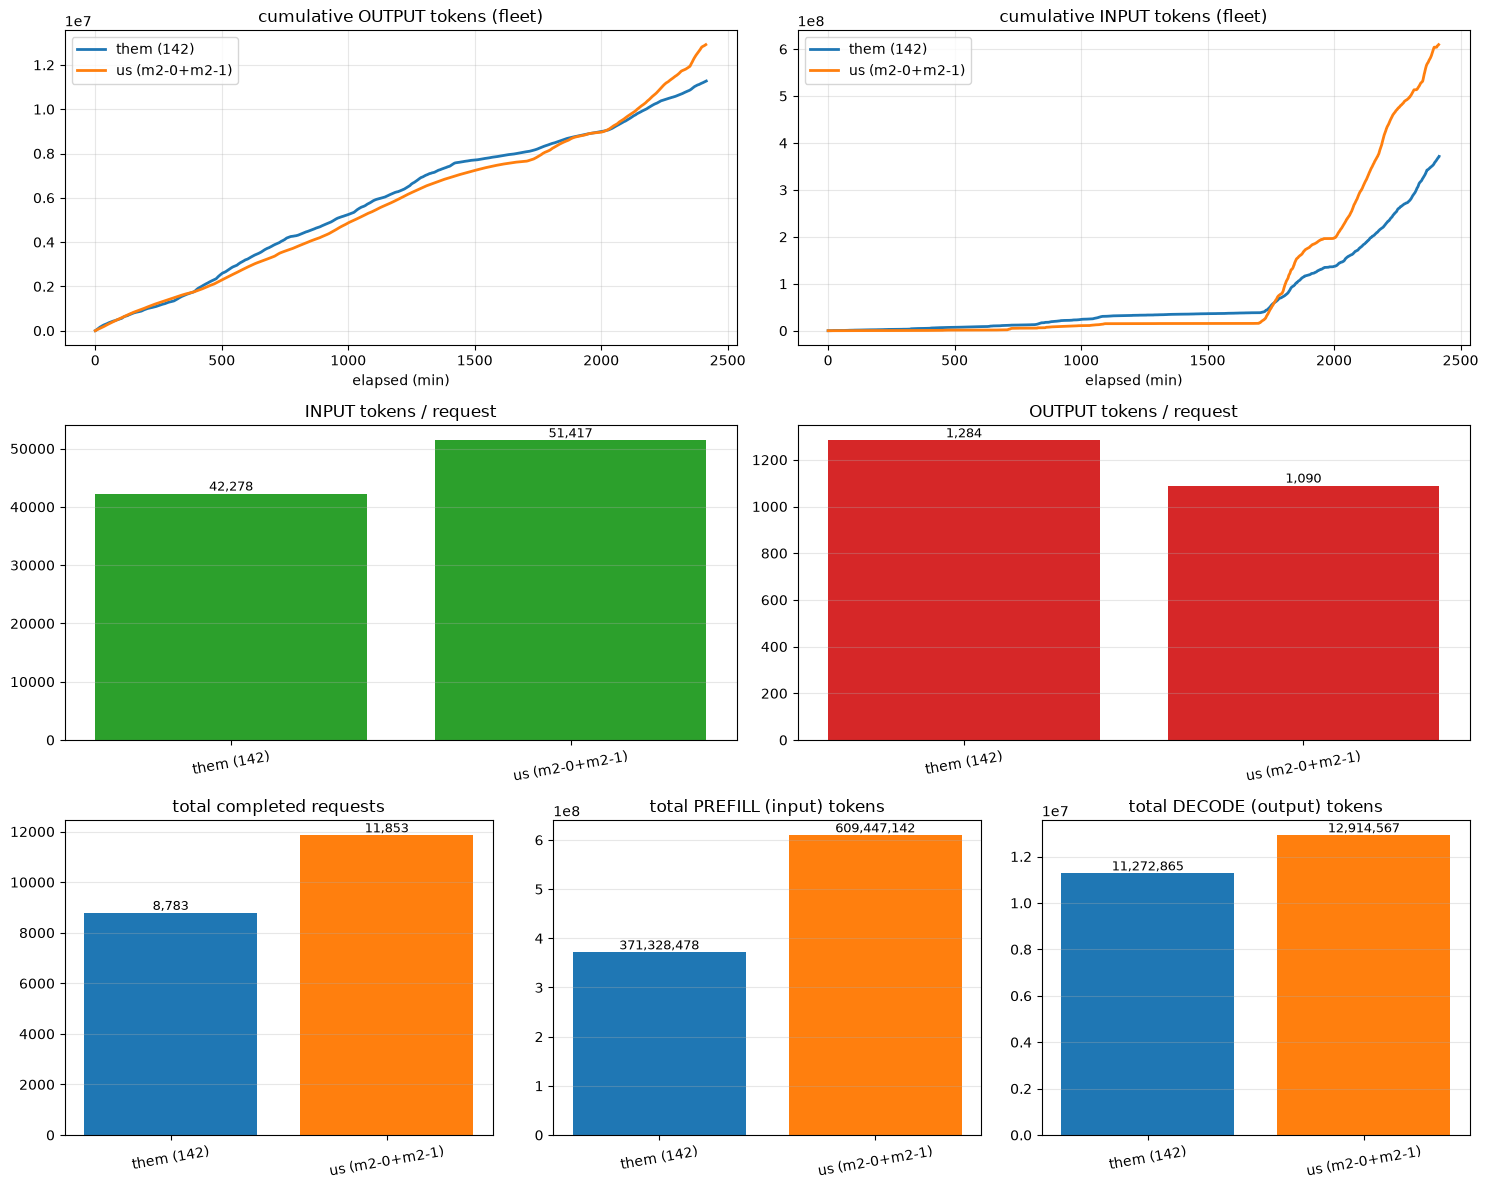

In [9]:
them_e = engine_rows(df95)                # 142 (external), 2 engines
us_e   = engine_rows(df96, US_ENDPOINTS)  # ours, 4 engines


def _rowmean(df, col):
    return float(df[col].dropna().mean()) if (col in df.columns and df[col].notna().any()) else np.nan


# --- 1) e2e latency (confirm the gap) ---
lat = pd.DataFrame({
    "run": ["them (142)", "us (m2-0+m2-1)"],
    "engines": [them_e["endpoint_engine"].nunique(), us_e["endpoint_engine"].nunique()],
    "e2e_avg_s (vLLM)":  [_rowmean(them_e, "e2e_latency_seconds_avg"), _rowmean(us_e, "e2e_latency_seconds_avg")],
    "ttft_avg_s (vLLM)": [_rowmean(them_e, "ttft_seconds_avg"),        _rowmean(us_e, "ttft_seconds_avg")],
    # them: vLLM server-side percentiles; us: only router-side available (incl. queue wait)
    "e2e_p50_s":         [_rowmean(them_e, "e2e_p50"), _rowmean(df96, "router_e2e_p50")],
    "e2e_p95_s":         [_rowmean(them_e, "e2e_p95"), _rowmean(df96, "router_e2e_p95")],
}).set_index("run").round(3)
print("e2e_p50/p95: them = vLLM server-side; us = router-side (includes queue wait -> not directly comparable).")
if not np.isnan(lat["e2e_avg_s (vLLM)"]).any():
    _r = lat["e2e_avg_s (vLLM)"]["us (m2-0+m2-1)"] / lat["e2e_avg_s (vLLM)"]["them (142)"]
    print(f"CONFIRMED: server-side avg e2e for us is {_r:.1f}x them.")
display(lat)


# --- 2) cumulative tokens & per-request size (same prometheus method for BOTH) ---
# request counts: absolute request_success_total delta (reliable, no rate/window drift).
# token volumes: integral of the per-sec rates (add_cumulative, now resolution-safe).
def _totals(dfc):
    t = cumulative_totals(dfc)
    g = lambda c: float(t[c].sum()) if c in t.columns else np.nan
    return g("cum_requests"), g("cum_gen_tokens"), g("cum_prefill_tokens")


them_c, us_c = add_cumulative(them_e), add_cumulative(us_e)
tr, tg, tp = _totals(them_c)
ur, ug, up = _totals(us_c)
tok = pd.DataFrame({
    "run": ["them (142)", "us (m2-0+m2-1)"],
    "completed_requests":   [tr, ur],
    "gen_tokens_total":     [tg, ug],
    "prefill_tokens_total": [tp, up],
    "out_tokens_per_req":   [tg / tr, ug / ur],   # output / response length
    "in_tokens_per_req":    [tp / tr, up / ur],   # input / prompt length
}).set_index("run").round(1)
display(tok)
print(f"Prompt (input) size:  them = {tp/tr:,.0f} tok/req  vs  us = {up/ur:,.0f} tok/req  "
      f"(them = {(tp/tr)/(up/ur):.2f}x us -> them send SHORTER prompts).")
print(f"Output (vLLM-gen):    them = {tg/tr:,.0f} tok/req  vs  us = {ug/ur:,.0f} tok/req  "
      f"(them = {(tg/tr)/(ug/ur):.2f}x us -> similar output volume).")


# --- 3) plots ---
def _fleet_cum(dfc, col):
    d = dfc[dfc[col].notna()] if col in dfc.columns else dfc.iloc[0:0]
    if d.empty:
        return pd.DataFrame(columns=["elapsed_min", col])
    s = d.groupby("ts", as_index=False)[col].sum().sort_values("ts")
    s["elapsed_min"] = (s["ts"] - s["ts"].min()).dt.total_seconds() / 60.0
    return s


fig, axd = plt.subplot_mosaic(
    [["cum_out", "cum_out", "cum_out", "cum_in", "cum_in", "cum_in"],
     ["in_req", "in_req", "in_req", "out_req", "out_req", "out_req"],
     ["t_req", "t_req", "t_prefill", "t_prefill", "t_decode", "t_decode"]],
    figsize=(15, 12))
# row 1: cumulative token volumes over time
for col, key, ttl in [("cum_gen_tokens", "cum_out", "cumulative OUTPUT tokens (fleet)"),
                      ("cum_prefill_tokens", "cum_in", "cumulative INPUT tokens (fleet)")]:
    ax = axd[key]
    for c, lab, color in [(them_c, "them (142)", "#1f77b4"), (us_c, "us (m2-0+m2-1)", "#ff7f0e")]:
        s = _fleet_cum(c, col)
        ax.plot(s["elapsed_min"], s[col], lw=2, label=lab, color=color)
    ax.set_xlabel("elapsed (min)"); ax.set_title(ttl); ax.grid(alpha=0.3); ax.legend()
# row 2: input and output tokens/request as separate bars (linear scale)
for col, key, ttl, color in [("in_tokens_per_req",  "in_req",  "INPUT tokens / request",  "#2ca02c"),
                            ("out_tokens_per_req", "out_req", "OUTPUT tokens / request", "#d62728")]:
    ax = axd[key]
    ax.bar(tok.index, tok[col], color=color)
    ax.set_title(ttl); ax.grid(alpha=0.3, axis="y")
    ax.tick_params(axis="x", rotation=10)
    for i, v in enumerate(tok[col]):
        ax.text(i, v, f"{v:,.0f}", ha="center", va="bottom", fontsize=9)
# row 3: totals - completed requests, prefill (input) tokens, decode (output) tokens
for col, key, ttl in [("completed_requests",   "t_req",     "total completed requests"),
                      ("prefill_tokens_total", "t_prefill", "total PREFILL (input) tokens"),
                      ("gen_tokens_total",      "t_decode",  "total DECODE (output) tokens")]:
    ax = axd[key]
    ax.bar(tok.index, tok[col], color=["#1f77b4", "#ff7f0e"])
    ax.set_title(ttl); ax.grid(alpha=0.3, axis="y")
    ax.tick_params(axis="x", rotation=10)
    for i, v in enumerate(tok[col]):
        ax.text(i, v, f"{v:,.0f}", ha="center", va="bottom", fontsize=9)
fig.tight_layout(); plt.show()

# Validate: logs.json (exact) vs prometheus metrics (us / exp 96)

For **our** run we have `logs.json` with the exact per-request `prompt_tokens` (prefill)
and `completion_tokens` (decode), so we can check how close the prometheus rate-integral
gets to the true totals.

- **requests** & **prefill/input tokens** should match closely (small integration error).
- **decode/output tokens** will differ: `vllm:generation_tokens_total` counts tokens the
  engine *generated* (including preemption/recompute), while `logs.json` counts tokens
  actually *delivered* to the client - so metrics > logs is expected and is a preemption
  signal, not an error.

,logs (exact),metrics (prom),metrics/logs,diff_%
quantity,,,,
completed requests,12232.0,11853.0,0.969,-3.1
prefill (input) tokens,656340689.0,609447142.0,0.929,-7.1
decode (output) tokens,5134461.0,12914567.0,2.515,151.5


requests: logs=12,232  metrics=11,853  (-3.1%)
prefill : logs=656,340,689  metrics=609,447,142  (-7.1%)
decode  : logs=5,134,461  metrics=12,914,567  (+151.5%)  <- metrics = generated (incl. recompute), logs = delivered


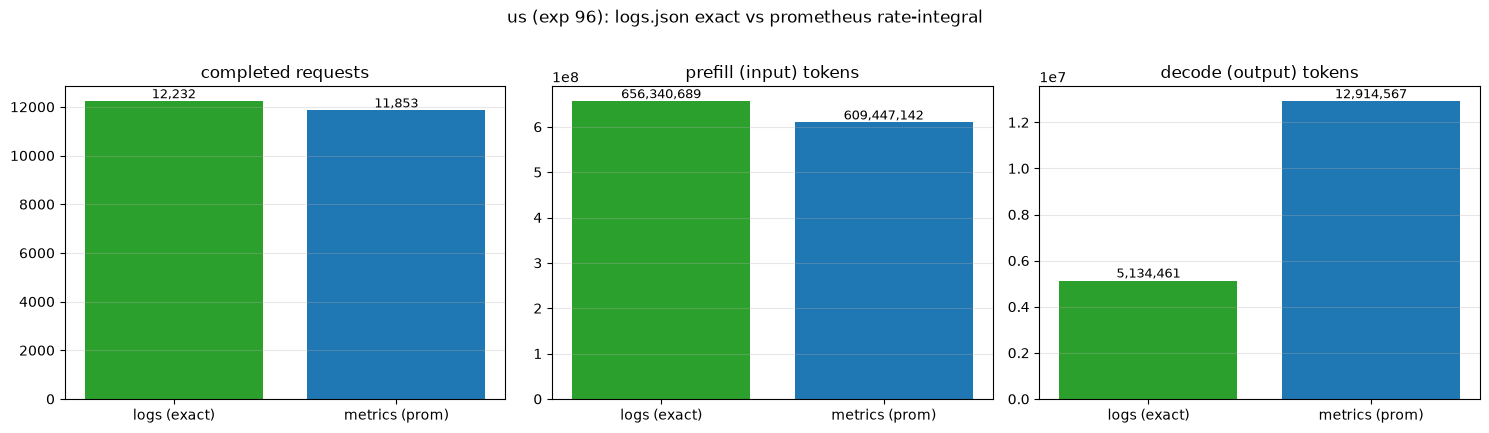

In [10]:
# exact per-request ground truth from logs.json (our run only)
_recs = [json.loads(l) for l in open(os.path.join(EXPERIMENTS_ROOT, "96", "logs.json")) if l.strip()]
log_req     = float(len(_recs))
log_prefill = float(np.nansum([(r.get("prompt_tokens") or 0) for r in _recs]))
log_decode  = float(np.nansum([(r.get("completion_tokens") or 0) for r in _recs]))

# metrics side: prometheus rate-integral for our endpoints (same method as comparison cell)
_usc = add_cumulative(engine_rows(df96, US_ENDPOINTS))
_t = cumulative_totals(_usc)
met_req     = float(_t["cum_requests"].sum())
met_prefill = float(_t["cum_prefill_tokens"].sum())
met_decode  = float(_t["cum_gen_tokens"].sum())

cmp = pd.DataFrame({
    "quantity":       ["completed requests", "prefill (input) tokens", "decode (output) tokens"],
    "logs (exact)":   [log_req, log_prefill, log_decode],
    "metrics (prom)": [met_req, met_prefill, met_decode],
}).set_index("quantity")
cmp["metrics/logs"] = cmp["metrics (prom)"] / cmp["logs (exact)"]
cmp["diff_%"] = (cmp["metrics/logs"] - 1.0) * 100.0
display(cmp.round({"logs (exact)": 0, "metrics (prom)": 0, "metrics/logs": 3, "diff_%": 1}))

print(f"requests: logs={log_req:,.0f}  metrics={met_req:,.0f}  ({(met_req/log_req-1)*100:+.1f}%)")
print(f"prefill : logs={log_prefill:,.0f}  metrics={met_prefill:,.0f}  ({(met_prefill/log_prefill-1)*100:+.1f}%)")
print(f"decode  : logs={log_decode:,.0f}  metrics={met_decode:,.0f}  ({(met_decode/log_decode-1)*100:+.1f}%)"
      f"  <- metrics = generated (incl. recompute), logs = delivered")

# grouped bars, one panel per quantity (different scales)
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, q in zip(axes, cmp.index):
    vals = [cmp.loc[q, "logs (exact)"], cmp.loc[q, "metrics (prom)"]]
    bars = ax.bar(["logs (exact)", "metrics (prom)"], vals, color=["#2ca02c", "#1f77b4"])
    ax.set_title(q); ax.grid(alpha=0.3, axis="y")
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width() / 2, v, f"{v:,.0f}", ha="center", va="bottom", fontsize=9)
fig.suptitle("us (exp 96): logs.json exact vs prometheus rate-integral", y=1.02)
fig.tight_layout(); plt.show()